### Program 2

1. imports

In [16]:
import numpy
import keras
from math import sqrt
from keras import layers, Input, Model, optimizers
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
import numpy as np

plt.style.use('dark_background')

1.2 auxiliary methods

In [26]:
def get_accuracy(y_test, y_predictions) -> float :
    assert len(y_test) == len(y_predictions)
    correct: int = 0

    for t, p in zip (y_test, y_predictions):
        if t == p:
            correct += 1

    return correct / len(y_test)


def sub_plot_decision_boundary(y_predictions, X_test, y_test, ax):
    x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
    y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    Z = y_predictions

    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)

def plot_performance_evaluation(ax, model_name, X_test, y_test, y_predictions):
    accuracy: str = str(get_accuracy(y_test, y_predictions) * 100) + "%"

    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_predictions, marker="o",s=50)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker=".")
    plt.title(str(model_name) + " | accuracy : " + accuracy)

    legend_elements = [
          Line2D([0], [0], marker='o', color='w', label='Predicted label', markersize=8),
          Line2D([0], [0], marker='.', color='w', label='True label', markersize=8),
    ]
    ax.legend(handles=legend_elements, title="Classification outcomes", loc='lower right')

2. generate a dataset

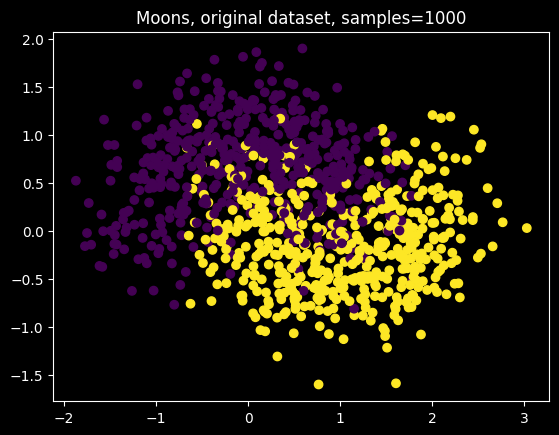

In [17]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1_000, noise=0.4)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Moons, original dataset, samples=" + str(len(X[:, 0])))
plt.show()

3. split data into test and training sets

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

4. plot test set, train set and original data

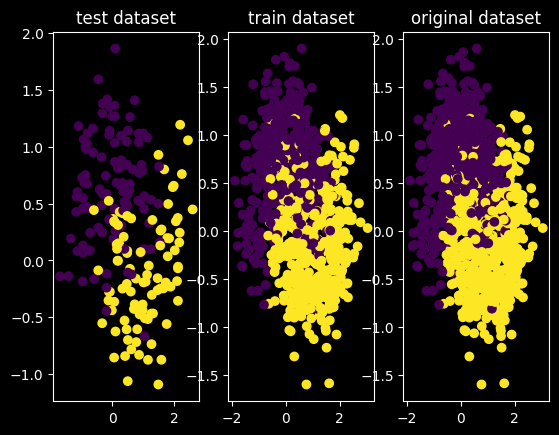

<Figure size 640x480 with 0 Axes>

In [19]:
_, (test_plot, train_plot, org_plot) = plt.subplots(1,3)

test_plot.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
test_plot.set_title("test dataset")
train_plot.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
train_plot.set_title("train dataset")
org_plot.scatter(X[:, 0], X[:, 1], c=y)
org_plot.set_title("original dataset")

plt.show()
plt.savefig("output/input_data.png")

5. define model

In [20]:
inputs = Input(shape=(2,), name="input_features")
x = layers.Dense(4, activation="relu", name="hidden_layer_1")(inputs)
outputs = layers.Dense(1, activation="sigmoid", name="predicted_value")(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="binary_classifier"
)

6. compile model

In [21]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

7. train model

In [23]:
batch_size = int(sqrt(len(X_train)))

model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=batch_size,
    validation_split=0.2
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8656 - loss: 0.3231 - val_accuracy: 0.8562 - val_loss: 0.3309
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8672 - loss: 0.3246 - val_accuracy: 0.8625 - val_loss: 0.3299
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8672 - loss: 0.3193 - val_accuracy: 0.8625 - val_loss: 0.3346
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8687 - loss: 0.3212 - val_accuracy: 0.8375 - val_loss: 0.3277
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8734 - loss: 0.3174 - val_accuracy: 0.8562 - val_loss: 0.3268
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8750 - loss: 0.3116 - val_accuracy: 0.8562 - val_loss: 0.3323
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8734 - loss: 0.3104 - val_accuracy: 0.8562 - val_loss: 0.3271
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8687 - loss: 0.3083 - val_accuracy: 0.8500 - val_loss:

8. evaluate model

In [27]:
predictions_as_probabilities = model.predict(X_test)
predicted_labels = (predictions_as_probabilities >= 0.5).astype("int32")


get_accuracy(X_test, predicted_labels)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()